In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder 
from tensorflow.keras.utils import to_categorical, plot_model
import os

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = []
result = []

# 🍅 Tomatoes
for r, d, f in os.walk("D:\\Apples & Tomatoes (1)\\tomatoes pic\\tomatoes"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0   # 🔥 normalization

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([0, 1])   # tomato

# Apples

In [3]:
for r, d, f in os.walk("D:\\Apples & Tomatoes (1)\\apples pic\\apples"):
    for file in f:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            path = os.path.join(r, file)

            img = Image.open(path)
            img = img.resize((128, 128))
            img = np.array(img) / 255.0

            if img.shape == (128, 128, 3):
                data.append(img)
                result.append([1, 0])

In [4]:
data = np.array(data)
result = np.array(result)

print("Data shape:", data.shape)      
print("Result shape:", result.shape)

Data shape: (290, 128, 128, 3)
Result shape: (290, 2)


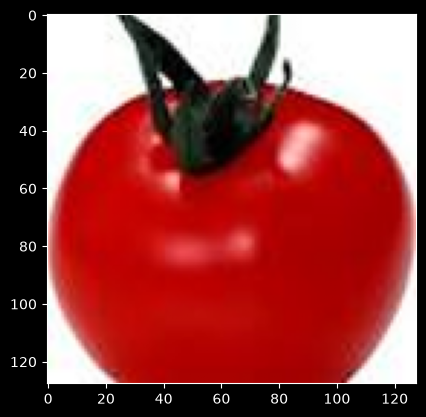

In [ ]:
plt.imshow(data[71]) # taking element(photo) in the data from the 67 th index 

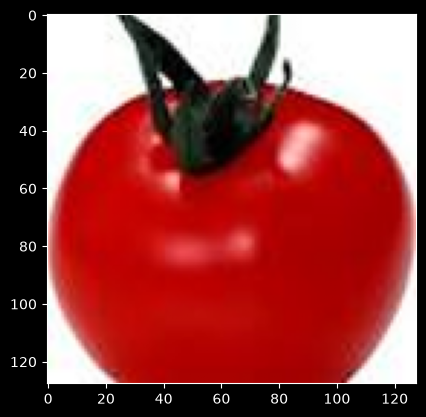

In [6]:
plt.imshow(data[71]) # taking element(photo) in the data from the 67 th index 

In [7]:
x_train, x_test, y_train, y_test = train_test_split(data, result, test_size=0.2, shuffle=True, random_state=42)

In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3), padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,621,922 (128.26 MB)

 Trainable params: 33,621,730 (128.26 MB)

 Non-trainable params: 192 (768.00 B)

None


In [9]:
model.compile(loss="binary_crossentropy",optimizer='adam',metrics=['accuracy'])

In [10]:
x_train.shape

(232, 128, 128, 3)

In [11]:
y_train.shape

(232, 2)

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    verbose=1,
    validation_data=(x_test, y_test))

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 53s 11s/step - accuracy: 0.4957 - loss: 36.0761 - val_accuracy: 0.4828 - val_loss: 0.9108
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 23s 5s/step - accuracy: 0.5431 - loss: 8.2222 - val_accuracy: 0.5172 - val_loss: 1.3658
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 6s/step - accuracy: 0.6853 - loss: 4.9341 - val_accuracy: 0.5172 - val_loss: 0.8911
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 26s 5s/step - accuracy: 0.7284 - loss: 2.4245 - val_accuracy: 0.5517 - val_loss: 1.0298
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 6s/step - accuracy: 0.7716 - loss: 1.3232 - val_accuracy: 0.5517 - val_loss: 1.4683
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 5s/step - accuracy: 0.8276 - loss: 0.9115 - val_accuracy: 0.6379 - val_loss: 1.4070
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 38s 9s/step - accuracy: 0.8491 - loss: 0.4993 - val_accuracy: 0.7586 - val_loss: 1.4416
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 32s 8s/step - accuracy: 0.8879 - loss: 0.3478 - val_accuracy: 0.6897 - val_loss: 1.5946
Epoch 

In [13]:
score = model.evaluate(x_test, y_test, batch_size=64)
print("\nTest accuracy: %.1f%%" % (100.0 * score[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 652ms/step - accuracy: 0.7069 - loss: 1.9361

Test accuracy: 70.7%


In [14]:


img_path = r"D:\\Apples & Tomatoes (1)\\apples pic\\apples\\img_p1_67.jpeg"
img = Image.open(img_path)
img = img.resize((128,128))
img = np.array(img) / 255.0   # 🔥 same preprocessing

img = np.expand_dims(img, axis=0)  # shape (1,128,128,3)

prediction = model.predict(img)
pred_class = np.argmax(prediction)

if pred_class == 0:
    print("Prediction: Apple")
else:
    print("Prediction:  Tomatoes")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 607ms/step
Prediction: Apple
